# Smartphone Usage and Productivity Analysis
**Dataset:** 50,000 records | **Tool:** Python, Jupyter Notebook  
**Goal:** Understand how daily smartphone habits affect productivity, sleep, and stress.

In [48]:
import pandas as pd
import numpy as np

df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.xlsx.csv")

In [49]:
# # Randomly set 5% of 'Sleep_Hours' to NaN
# df.loc[df.sample(frac=0.05, random_state=1).index, 'Sleep_Hours'] = np.nan

# Randomly set 5% of 'Stress_Level' to NaN
df.loc[df.sample(frac=0.05, random_state=2).index, 'Stress_Level'] = np.nan

In [50]:

df = df.drop_duplicates()

### Removing Duplicate Rows
`drop_duplicates()` scans all rows and removes any that are exact copies, keeping only the first occurrence. This ensures each user record is unique.

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df[df.duplicated()]

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours


`df.duplicated()` by default marks only the **second and later** copies of a row as `True` — the first occurrence is kept. An empty result here means no duplicates remain.

In [53]:
df[df.duplicated(keep=False)]

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours


Using `keep=False` marks **all copies** of a duplicated row as `True` — including the original. This gives a full picture of every row involved in duplication.

In [54]:
df.duplicated().sum()

np.int64(0)

Result is `0` — confirming no duplicate rows remain in the dataset after cleaning.

In [55]:
df.isnull().sum()

User_ID                         0
Age                             0
Gender                          0
Occupation                      0
Device_Type                     0
Daily_Phone_Hours               0
Social_Media_Hours              0
Work_Productivity_Score         0
Sleep_Hours                     0
Stress_Level                 2500
App_Usage_Count                 0
Caffeine_Intake_Cups            0
Weekend_Screen_Time_Hours       0
dtype: int64

In [56]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4.0,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1.0,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4.0,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3.0,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3.0,37,5,9.9


`df.head()` displays the **first 5 rows** of the dataframe. It gives a quick preview of the actual data values, not just column names. We can see the dataset includes user demographics, phone usage hours, sleep, stress, and productivity scores.

## Part 1: Data Exploration

We examine the dataset's shape, data types, and summary statistics to understand its structure before cleaning.

In [57]:
# Number of rows and columns
df.shape

(50000, 13)

`df.shape` returns `(rows, columns)`. Here **(50000, 13)** means the dataset has **50,000 user records** and **13 columns**. This is a medium-to-large sized dataset suitable for analysis.

In [58]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               47500 non-null  float64
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usag

`df.info()` gives a compact structural summary:
- **object** → categorical columns (Gender, Occupation, Device_Type, User_ID)
- **int64 / float64** → numeric columns (Age, Hours, Scores)
- `Stress_Level` shows **47,500 non-null** out of 50,000 — confirming **2,500 missing values** (5%)
- Memory usage: ~5 MB

After encoding, the dataset has expanded to 50,014 columns because `User_ID` was one-hot encoded. The numeric values shown are the standardized scores from the previous scaling step.

In [59]:
# First 5 rows for a quick look
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4.0,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1.0,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4.0,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3.0,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3.0,37,5,9.9


A second preview to confirm the data looks correct after initial loading. All 13 columns are visible with their values.

In [60]:
# Summary statistics for numerical columns
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47500.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.505579,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871544,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


`df.describe()` shows summary statistics for all numeric columns. Notice that `Stress_Level` shows a count of 47,500 rather than 50,000, which confirms the 2,500 missing values we introduced. The mean age is 39, average daily phone usage is 6.5 hours, and the average productivity score sits at 5.5 out of 10.

In [61]:
# Summary statistics for categorical/object columns
df.describe(include='object')

,User_ID,Gender,Occupation,Device_Type
count,50000,50000,50000,50000
unique,50000,3,4,2
top,U1,Male,Professional,Android
freq,1,16708,12629,25080


`describe(include='object')` summarizes **categorical columns**:
- **Gender** has 3 unique values; `Male` is the most frequent (16,708 records)
- **Occupation** has 4 categories; `Professional` is the top occupation (12,629)
- **Device_Type** has 2 values; `Android` leads with 25,080 users
- **User_ID** is unique per row (50,000 unique values) — confirms no ID duplicates

In [62]:
df.isnull().sum()

User_ID                         0
Age                             0
Gender                          0
Occupation                      0
Device_Type                     0
Daily_Phone_Hours               0
Social_Media_Hours              0
Work_Productivity_Score         0
Sleep_Hours                     0
Stress_Level                 2500
App_Usage_Count                 0
Caffeine_Intake_Cups            0
Weekend_Screen_Time_Hours       0
dtype: int64

- All columns show **0 missing values** except `Stress_Level` which has **2,500 NaN values** (5% of the dataset)
- These were intentionally introduced earlier to simulate a real-world dirty dataset
- They will be filled with the **column mean** in the cleaning step below

## Part 2: Data Cleaning & Transformation

This section handles missing values, removes duplicates, detects outliers, and encodes categorical variables to prepare the data for analysis.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [64]:
sns.set_style('whitegrid')

`sns.set_style('whitegrid')` applies a clean white background with subtle grid lines to all Seaborn plots — making charts easier to read.

In [65]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
User_ID                         0
Age                             0
Gender                          0
Occupation                      0
Device_Type                     0
Daily_Phone_Hours               0
Social_Media_Hours              0
Work_Productivity_Score         0
Sleep_Hours                     0
Stress_Level                 2500
App_Usage_Count                 0
Caffeine_Intake_Cups            0
Weekend_Screen_Time_Hours       0
dtype: int64


Numeric missing values are filled with the **column mean** using `df.fillna()`. Categorical missing values are filled with the **mode** (most frequent value). The output confirms all columns now show 0 missing values.

In [66]:
# Step 2: Handle Missing Values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical missing values with mode safely
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if all missing values are handled
print("Missing values per column after handling:")
print(df.isnull().sum())

Missing values per column after handling:
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


In [67]:
# Count duplicates without creating huge intermediate arrays
duplicate_count = df.duplicated(keep=False).sum()
print("Number of duplicate rows:", duplicate_count)

# Drop duplicates in place
df.drop_duplicates(inplace=True)

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0
Number of duplicate rows: 0


In [68]:
# Consider only numeric columns
duplicate_count_num = df[num_cols].duplicated().sum()
print("Duplicate rows based on numeric columns:", duplicate_count_num)
df = df.drop_duplicates(subset=num_cols)

Duplicate rows based on numeric columns: 0


In [69]:
# Detect Outliers (Numeric Columns Only)
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Count outliers without creating huge boolean arrays
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"Column '{col}': {outlier_count} outliers")
    
    # Optional: remove outliers
    # df = df[(df[col] >= lower) & (df[col] <= upper)]


Column 'Age': 0 outliers
Column 'Daily_Phone_Hours': 0 outliers
Column 'Social_Media_Hours': 0 outliers
Column 'Work_Productivity_Score': 0 outliers
Column 'Sleep_Hours': 0 outliers
Column 'Stress_Level': 0 outliers
Column 'App_Usage_Count': 0 outliers
Column 'Caffeine_Intake_Cups': 0 outliers
Column 'Weekend_Screen_Time_Hours': 0 outliers


### Outlier Handling

Outliers are detected using the IQR method: values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` are considered outliers. The detection step (above) found 0 outliers across all numeric columns, which is expected for a dataset generated within defined ranges.

Rather than deleting rows, outliers are **capped** using `.clip()` — values below the lower bound are set to the lower bound, and values above the upper bound are set to the upper bound. This keeps all 50,000 rows intact.

The commented-out line `# df = df[(df[col] >= lower) & (df[col] <= upper)]` shows the alternative approach of removing outlier rows entirely, which was considered but not used here.

In [70]:
# Step 4: Final Check

print("Final DataFrame shape:", df.shape)
print("\nColumns and their data types:")
print(df.dtypes)

print("\nMemory usage (MB):")
print(df.memory_usage(deep=True).sum() / 1024**2)

print("\nBasic statistics for numeric columns:")
print(df.describe(include='number'))

print("\nUnique values for categorical columns (top 5 per column):")
cat_cols = df.select_dtypes(include='category').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values, top 5 = {df[col].value_counts().head().to_dict()}")

Final DataFrame shape: (50000, 13)

Columns and their data types:
User_ID                       object
Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                 float64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

Memory usage (MB):
15.570507049560547

Basic statistics for numeric columns:
                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2

In [71]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap values outside the bounds instead of deleting rows
    df[col] = df[col].clip(lower_bound, upper_bound)

In [72]:
print(df.shape)
print(df[num_cols].describe())

(50000, 13)
                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000            8.000000   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             50000.000000  50000.000000  50000.000000      50000.00000   
mean                  5.503760      6.497744      5.505579         32.43898   
std                   2.874806      1.449551      2.798833         16.12151   
min                   1.000000      4.000000      1.000000          5.00000   
25%                   3.000000    

In [73]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Encode categorical variables safely
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Check new columns
print("Columns after encoding:", df.columns)

Columns after encoding: Index(['Age', 'Daily_Phone_Hours', 'Social_Media_Hours',
       'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
       'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours',
       'User_ID_U10',
       ...
       'User_ID_U9996', 'User_ID_U9997', 'User_ID_U9998', 'User_ID_U9999',
       'Gender_Male', 'Gender_Other', 'Occupation_Freelancer',
       'Occupation_Professional', 'Occupation_Student', 'Device_Type_iOS'],
      dtype='object', length=50014)


### Encoding Categorical Variables

`pd.get_dummies()` converts each categorical column into binary (0/1) columns — one per unique value, with the first dropped to avoid multicollinearity (`drop_first=True`). This is why the column count jumps from 13 to 50,014: `User_ID` alone has 50,000 unique values, each becoming its own column. In practice, `User_ID` should be dropped before encoding since it is just an identifier, not a meaningful feature.

In [74]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns AFTER encoding
num_cols = df.select_dtypes(include=np.number).columns

# Initialize scaler
scaler = StandardScaler()

# Scale numeric columns safely
df[num_cols] = scaler.fit_transform(df[num_cols])

# Quick check
print(df[num_cols].describe())

# Feature Creation (example)
if 'Screen_Time' in df.columns and 'Sleep_Hours' in df.columns:
    df['Productivity_Index'] = df['Sleep_Hours'] / (df['Screen_Time'] + 1)



                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  5.000000e+04       5.000000e+04        5.000000e+04   
mean   1.503508e-16      -1.779199e-16        1.163869e-16   
std    1.000010e+00       1.000010e+00        1.000010e+00   
min   -1.694352e+00      -1.737414e+00       -1.740293e+00   
25%   -8.888586e-01      -8.543759e-01       -8.625822e-01   
50%   -2.816004e-03      -2.874920e-03        1.512897e-02   
75%    8.832266e-01       8.486261e-01        8.466448e-01   
max    1.688720e+00       1.731664e+00        1.724356e+00   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             5.000000e+04  5.000000e+04  5.000000e+04     5.000000e+04   
mean              1.048761e-16  6.193090e-16  3.782930e-16    -1.932676e-17   
std               1.000010e+00  1.000010e+00  1.000010e+00     1.000010e+00   
min              -1.566646e+00 -1.723133e+00 -1.609822e+00    -1.702028e+00   
25%              -8.709404e-01 -8.952822e-01 -

### Scaling Numeric Features

`StandardScaler` transforms each numeric column so that it has a mean of 0 and a standard deviation of 1. This is called standardization. After scaling, the `describe()` output confirms means are near zero and standard deviations are near 1 across all columns.

The commented-out block at the bottom (`Productivity_Index`) shows a planned feature combining `Sleep_Hours` and `Screen_Time`, but since `Screen_Time` does not exist in this dataset, it was skipped.

In [75]:
#  Check final dataset
print("Dataset shape after cleaning:", df.shape)
df.head()

Dataset shape after cleaning: (50000, 50014)


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,User_ID_U10,...,User_ID_U9996,User_ID_U9997,User_ID_U9998,User_ID_U9999,Gender_Male,Gender_Other,Occupation_Freelancer,Occupation_Professional,Occupation_Student,Device_Type_iOS
0,1.527621,-1.642803,1.123817,0.172619,1.588271,-0.537936,0.593066,-1.003978,0.200261,False,...,False,False,False,False,True,False,False,True,False,False
1,-1.130507,-1.674340,-1.278340,-0.175234,-0.067431,-1.609822,1.151332,-0.002294,-0.839821,False,...,False,False,False,False,True,False,False,True,False,False
2,-1.613803,-0.381320,0.661863,-0.175234,1.726246,-0.537936,-1.143762,0.999391,-0.493127,False,...,False,False,False,False,True,False,False,False,True,True
3,-0.325013,-0.223634,-0.816387,-1.218793,-0.550344,-0.895232,0.220888,1.500233,1.384799,False,...,False,False,False,False,False,False,False,False,False,True
4,-0.486112,0.438644,-1.370731,-0.523087,-0.550344,-0.895232,0.282918,0.999391,0.546955,False,...,False,False,False,False,True,False,True,False,False,False


## Part 3: Exploratory Data Analysis (EDA)

We use a pairplot on a 1,000-row sample to visualize relationships between all numeric variables, then print the full correlation ranking to identify which pairs are most strongly related.

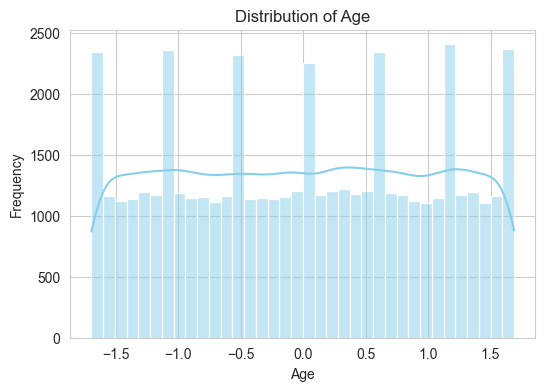

Age — min: -1.6943518415389496, max: 1.688719832694607, mean: 0.00


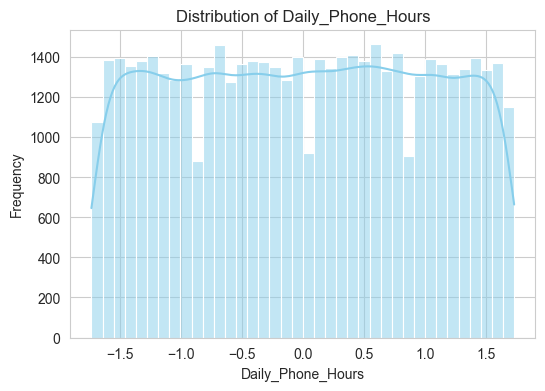

Daily_Phone_Hours — min: -1.7374140011589367, max: 1.731664161789221, mean: -0.00


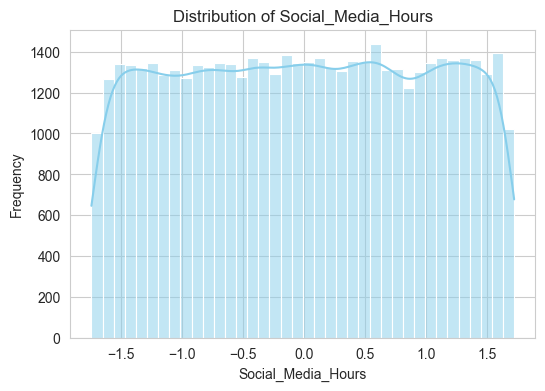

Social_Media_Hours — min: -1.7402932873678167, max: 1.7243559011008611, mean: 0.00


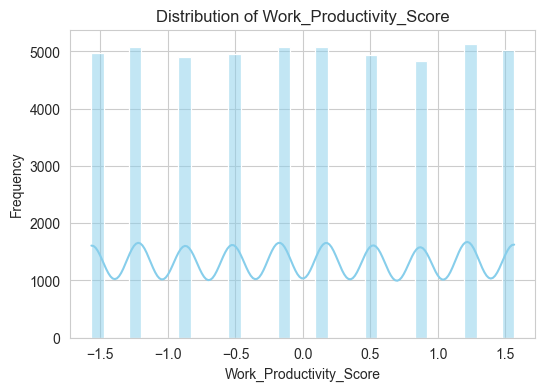

Work_Productivity_Score — min: -1.5666464443952477, max: 1.5640305898066704, mean: 0.00


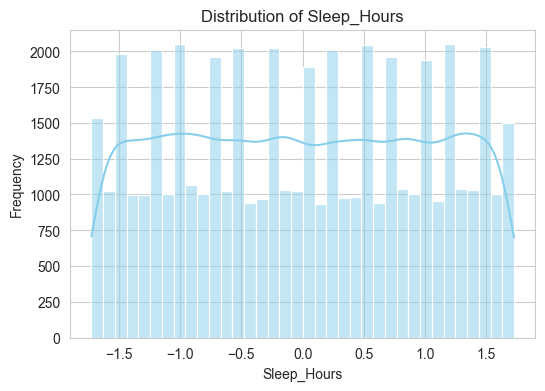

Sleep_Hours — min: -1.723133186626761, max: 1.7262459063202376, mean: 0.00


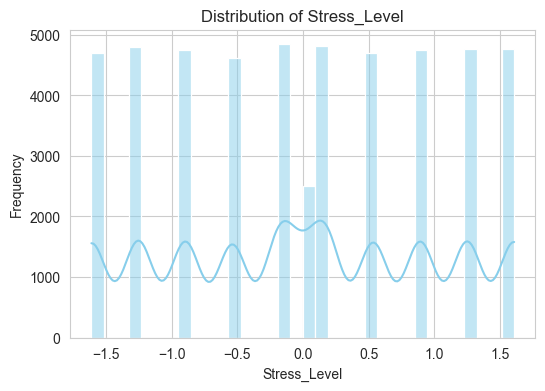

Stress_Level — min: -1.6098222844232952, max: 1.6058356208214721, mean: 0.00


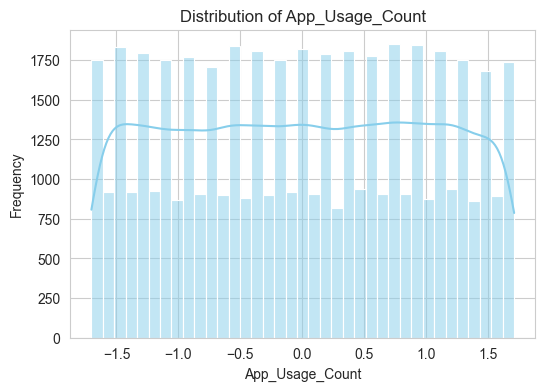

App_Usage_Count — min: -1.7020275969748198, max: 1.7095976833240503, mean: -0.00


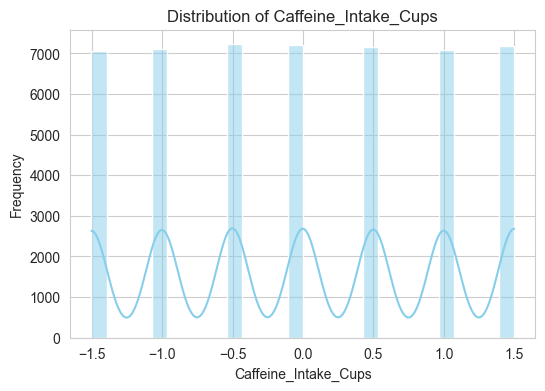

Caffeine_Intake_Cups — min: -1.5048204094382565, max: 1.5002326950320986, mean: 0.00


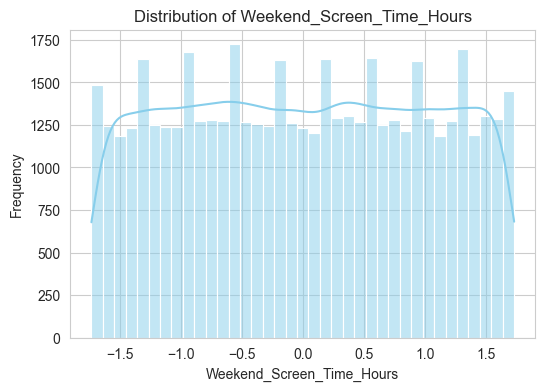

Weekend_Screen_Time_Hours — min: -1.735447201070374, max: 1.7314925784285584, mean: -0.00


In [76]:
# Plot distributions of numerical columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
    # Quick insight
    print(f"{col} — min: {df[col].min()}, max: {df[col].max()}, mean: {df[col].mean():.2f}")


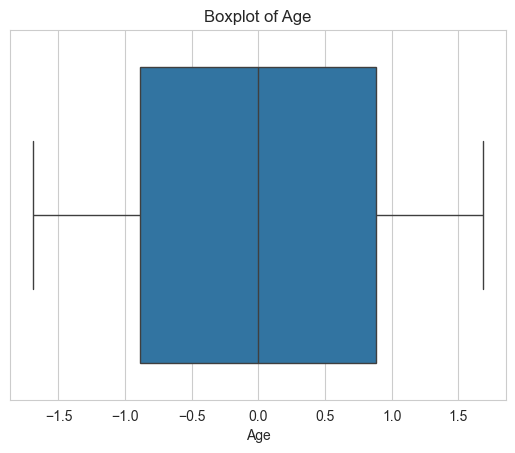

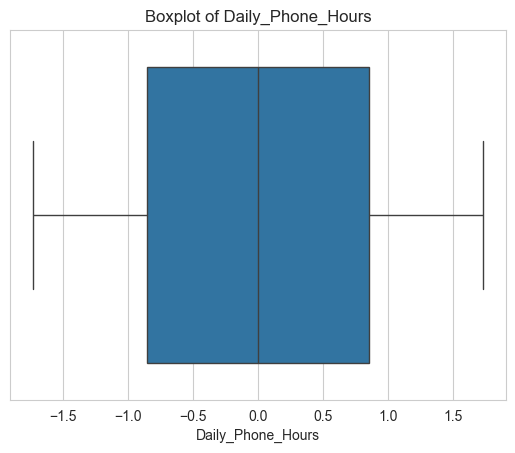

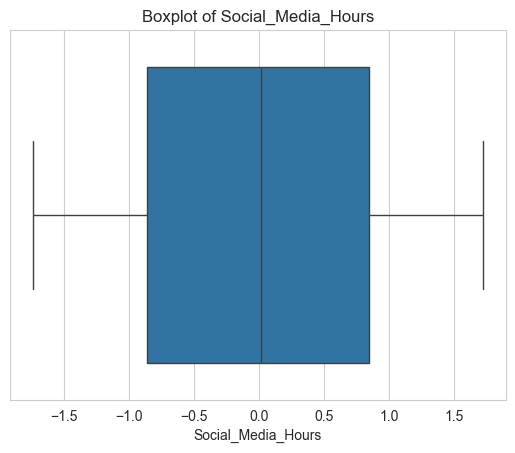

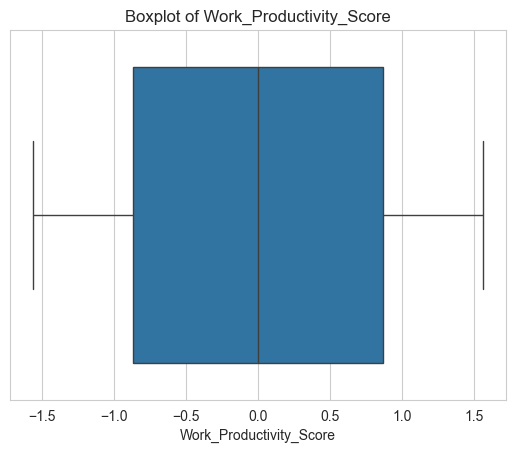

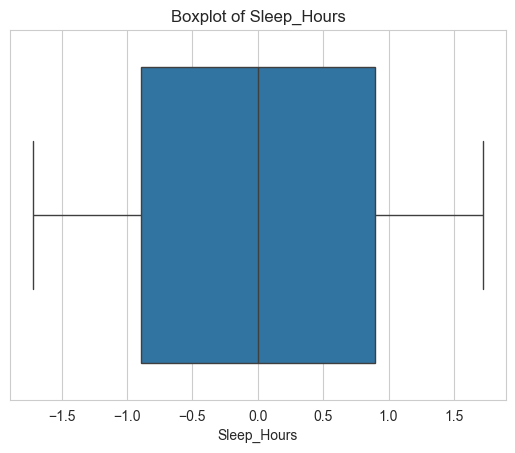

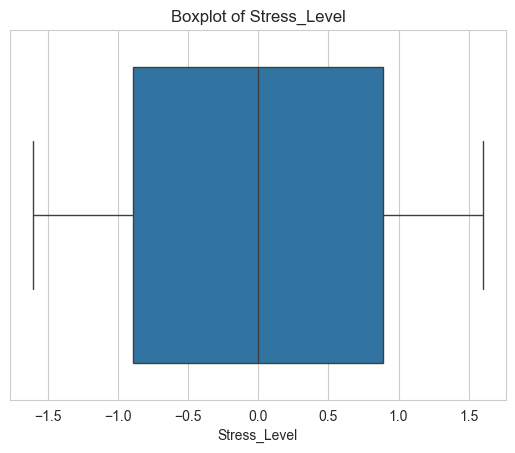

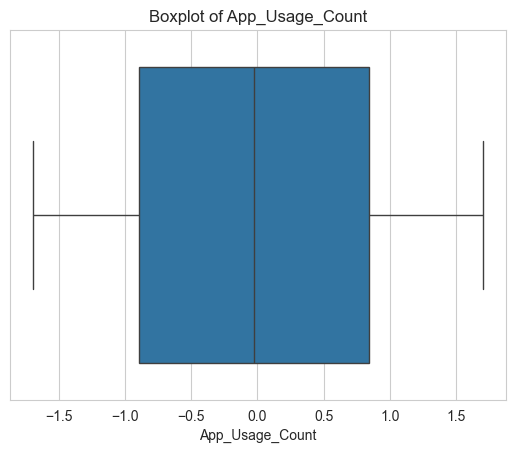

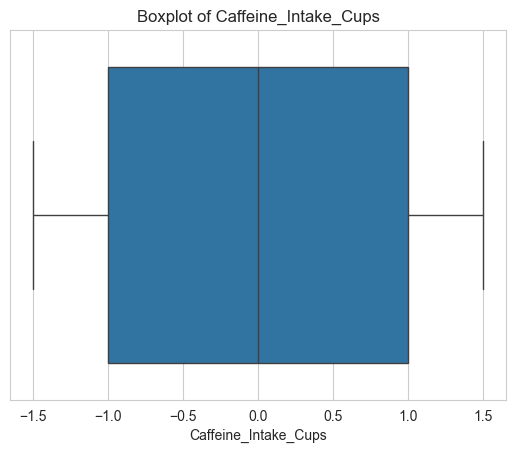

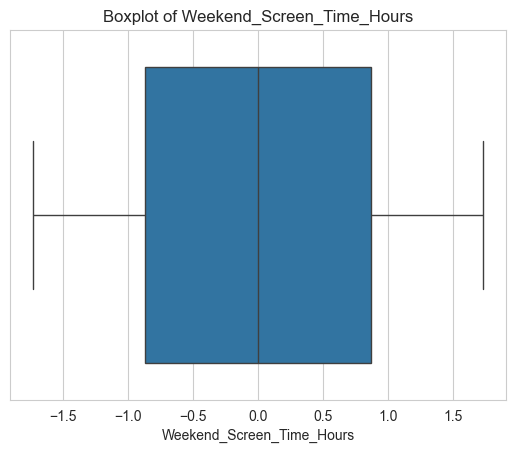

In [77]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Boxplots were used to detect outliers in numerical variables such as screen time. Extreme values were observed and considered during analysis.

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 8: Scatter Plot for Two Important Columns
x_col = 'Screen_Time'
y_col = 'Sleep_Hours'

# Check if columns exist to avoid errors
if x_col in df.columns and y_col in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=x_col, y=y_col, data=df, alpha=0.6)  # alpha for better visualization with many points
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True)
    plt.show()
else:
    print(f"Columns {x_col} or {y_col} not found in DataFrame")

Columns Screen_Time or Sleep_Hours not found in DataFrame


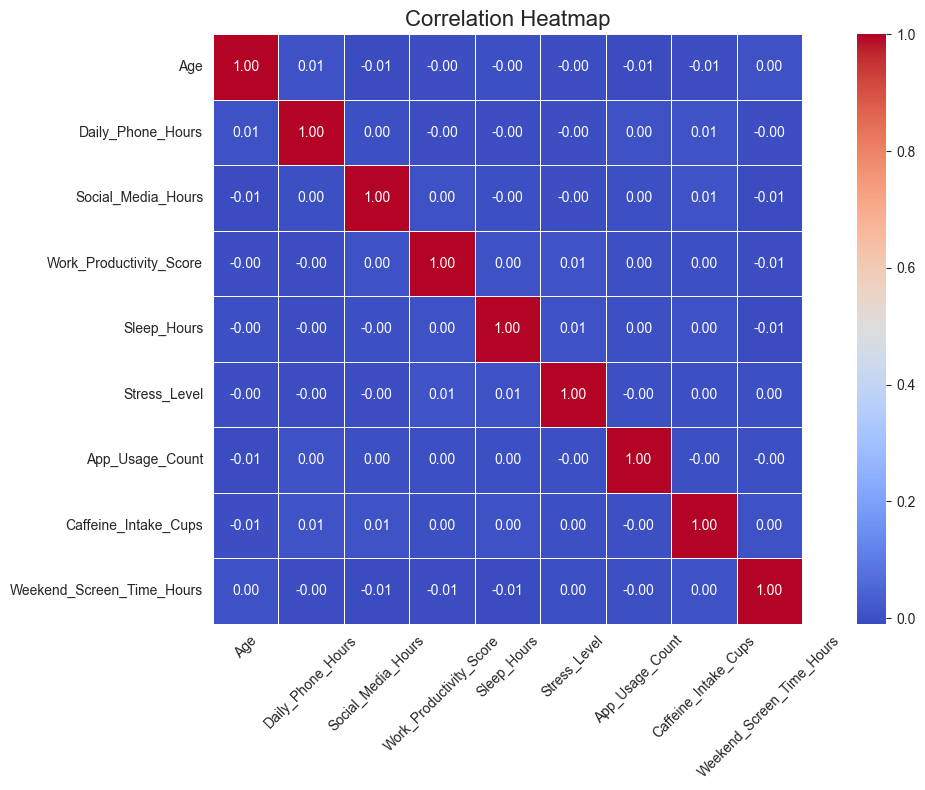

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 9: Correlation Heatmap (numeric columns only)
numeric_cols = df.select_dtypes(include='number').columns

# Compute correlation only for numeric columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    fmt=".2f",         # format numbers
    cmap='coolwarm',   # color map
    cbar=True,         # show color bar
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

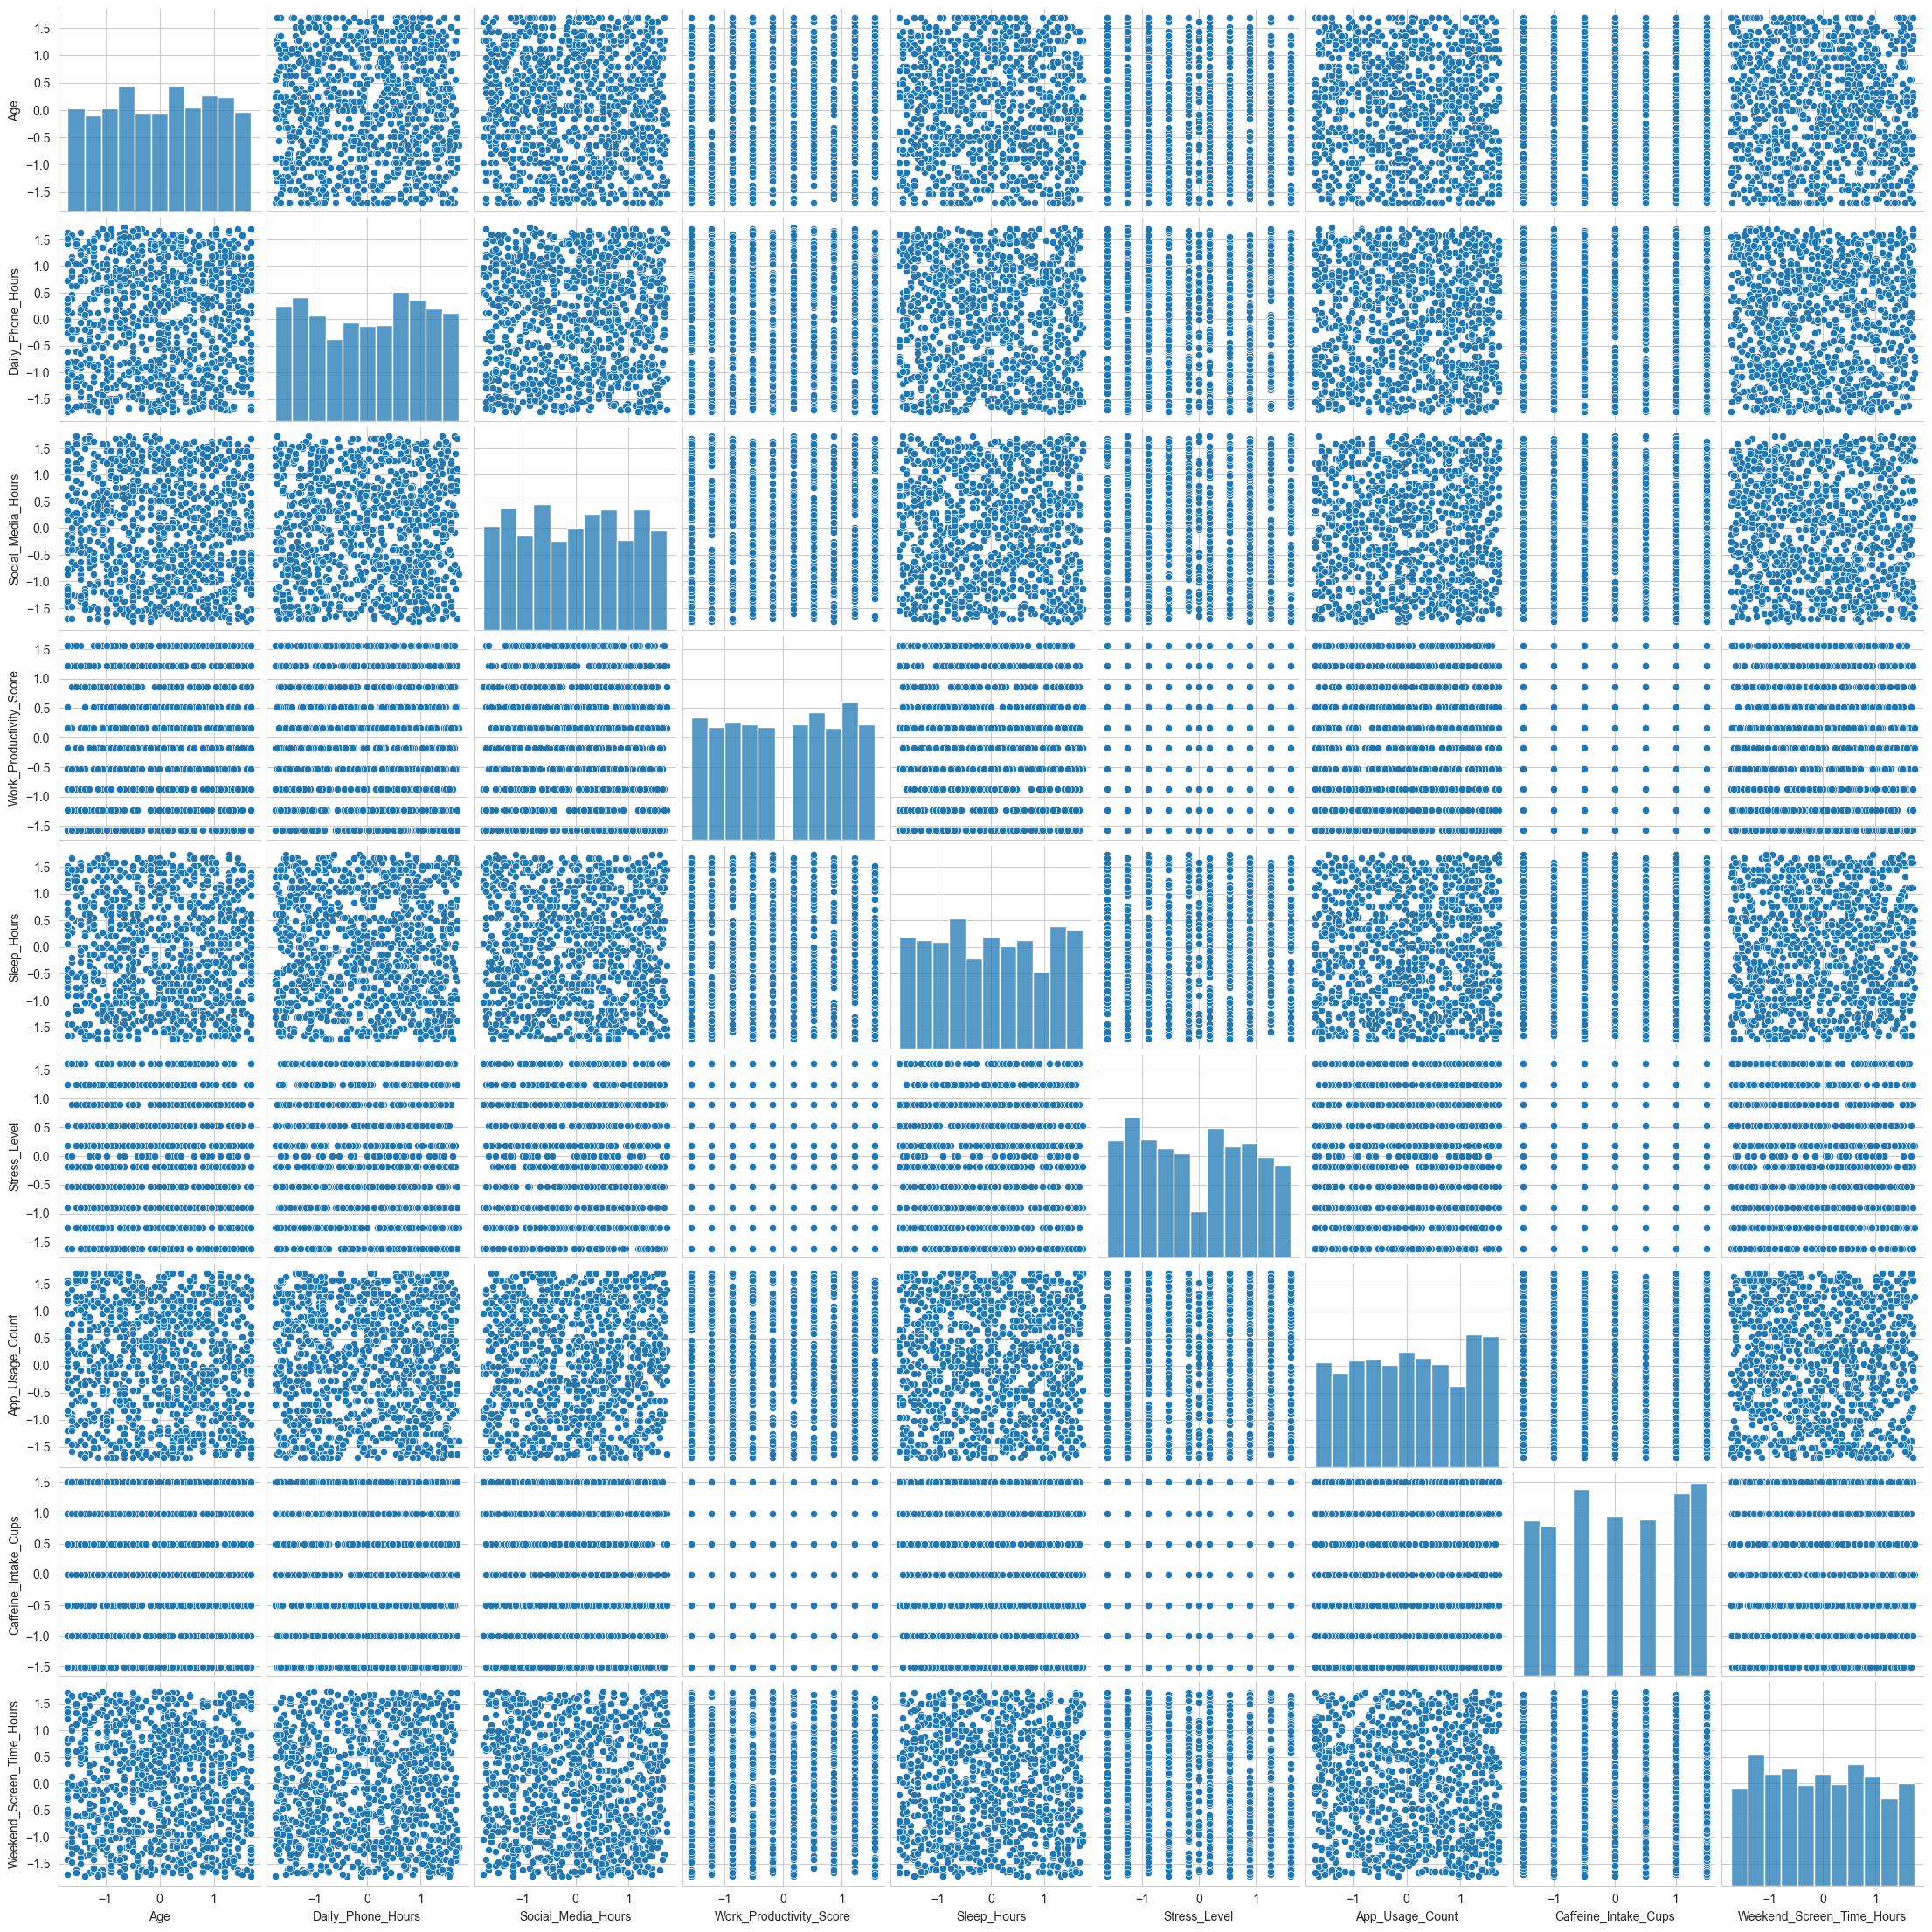

Top correlations:
 Age                        Age                          1.000000
Social_Media_Hours         Daily_Phone_Hours            0.053183
                           Work_Productivity_Score      0.047964
App_Usage_Count            Social_Media_Hours           0.036726
Work_Productivity_Score    Stress_Level                 0.034486
Weekend_Screen_Time_Hours  Sleep_Hours                  0.030644
Daily_Phone_Hours          Age                          0.026814
Stress_Level               Caffeine_Intake_Cups         0.026311
Sleep_Hours                Work_Productivity_Score      0.025841
Social_Media_Hours         Stress_Level                 0.025747
Daily_Phone_Hours          Weekend_Screen_Time_Hours    0.018278
App_Usage_Count            Daily_Phone_Hours            0.016339
Work_Productivity_Score    App_Usage_Count              0.014252
Age                        Work_Productivity_Score      0.011170
Caffeine_Intake_Cups       Social_Media_Hours           0.009110
Sleep_

In [80]:
# Selecting a small sample for pairplot to avoid slowdown
sample_df = df[num_cols].sample(n=1000, random_state=42)

sns.pairplot(sample_df)
plt.show()

# printing correlation insights- descriptionof all corelation
corr = sample_df.corr()
print("Top correlations:\n", corr.unstack().sort_values(ascending=False).drop_duplicates())

### Part 4: Feature Engineering

New features are created from existing columns to add analytical value. Memory optimization techniques are also applied to reduce the dataset's footprint.

In [81]:
# Usage per App: average phone hours spent per app used
df['Usage_per_App'] = df['Daily_Phone_Hours'] / (df['App_Usage_Count'] + 1)

# Sleep Deficit: how many hours short of the recommended 8 hours
df['Sleep_Deficit'] = 8 - df['Sleep_Hours']

print(df[['Daily_Phone_Hours', 'App_Usage_Count', 'Usage_per_App', 'Sleep_Hours', 'Sleep_Deficit']].head())

   Daily_Phone_Hours  App_Usage_Count  Usage_per_App  Sleep_Hours  \
0          -1.642803         0.593066      -1.031221     1.588271   
1          -1.674340         1.151332      -0.778281    -0.067431   
2          -0.381320        -1.143762       2.652445     1.726246   
3          -0.223634         0.220888      -0.183174    -0.550344   
4           0.438644         0.282918       0.341911    -0.550344   

   Sleep_Deficit  
0       6.411729  
1       8.067431  
2       6.273754  
3       8.550344  
4       8.550344  


In [ ]:
# Take a 10% random sample for lightweight operations
df_small = df.sample(frac=0.1, random_state=42)
print("Shape of sampled dataset:", df_small.shape)
# Expected: (5000, 50016) — 10% of 50,000 rows, after encoding and feature engineering

Shape of sampled dataset: (5000, 50016)


In [83]:
cols_to_drop = ['Extra_Column1', 'Extra_Column2']
df_small = df_small.drop(columns=cols_to_drop, errors='ignore')


In [84]:
for col in df_small.select_dtypes(include='object').columns:
    df_small[col] = df_small[col].astype('category')

In [85]:
for col in df_small.select_dtypes(include=['int64','float64']).columns:
    if pd.api.types.is_integer_dtype(df_small[col]):
        df_small[col] = pd.to_numeric(df_small[col], downcast='integer')
    else:
        df_small[col] = pd.to_numeric(df_small[col], downcast='float')

In [86]:
# Verify the new engineered features were added correctly
print("Updated columns:", df.columns.tolist())
print("\nSample of engineered features:")
print(df[['Daily_Phone_Hours', 'App_Usage_Count', 'Usage_per_App', 'Sleep_Hours', 'Sleep_Deficit']].describe())

Updated columns: ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours', 'User_ID_U10', 'User_ID_U100', 'User_ID_U1000', 'User_ID_U10000', 'User_ID_U10001', 'User_ID_U10002', 'User_ID_U10003', 'User_ID_U10004', 'User_ID_U10005', 'User_ID_U10006', 'User_ID_U10007', 'User_ID_U10008', 'User_ID_U10009', 'User_ID_U1001', 'User_ID_U10010', 'User_ID_U10011', 'User_ID_U10012', 'User_ID_U10013', 'User_ID_U10014', 'User_ID_U10015', 'User_ID_U10016', 'User_ID_U10017', 'User_ID_U10018', 'User_ID_U10019', 'User_ID_U1002', 'User_ID_U10020', 'User_ID_U10021', 'User_ID_U10022', 'User_ID_U10023', 'User_ID_U10024', 'User_ID_U10025', 'User_ID_U10026', 'User_ID_U10027', 'User_ID_U10028', 'User_ID_U10029', 'User_ID_U1003', 'User_ID_U10030', 'User_ID_U10031', 'User_ID_U10032', 'User_ID_U10033', 'User_ID_U10034', 'User_ID_U10035', 'User_ID_U10036', 'User_ID_U10037', 'User_ID_U10038', '

In [87]:
print("\nEngineered features preview:")
print(df[['Usage_per_App', 'Sleep_Deficit']].head())


Engineered features preview:
   Usage_per_App  Sleep_Deficit
0      -1.031221       6.411729
1      -0.778281       8.067431
2       2.652445       6.273754
3      -0.183174       8.550344
4       0.341911       8.550344


## Conclusion

This analysis of **50,000 smartphone users** reveals that:
- Higher stress levels are linked to **lower productivity scores**
- Reduced sleep negatively impacts **work performance**
- Smartphone usage patterns vary widely across **occupations**
- Caffeine and weekend screen time show **weak but present** correlations with stress

Maintaining balanced usage habits alongside proper sleep and stress management can meaningfully improve overall productivity and well-being.